# Supply Chain Data Exploration

## Project Overview
I was provided with three tables without additional context or information. The idea was to explore the tables and provide some insights within a limited timeframe.
This project demonstrates leveraging `Python` and `SQL` for data profiling, querying, and visualization through structured logistics data exploration.

### Objectives:
- Load CSV files into database tables.
- Conduct exploratory data analysis (EDA) using SQL.
- Identify key business insights through profiling and visualization.

### Data Sources:
The project leverages three primary datasets:
- `files`: Customer transactions involving shipments and services.
- `containers`: Shipment containers linked to transactions.
- `customers`: Unique customer details.

> **Note on data:** `data/` ships a deterministic ~5% customer sample of the original extracts
> (22,257 of 578,215 shipment records; full history kept for every sampled customer) because the
> full files exceed GitHub size limits. Referential structure is preserved — including customers
> that appear in `files` but not in `customers`, and vice versa — so every check below still
> behaves like the original. All identifiers were already anonymized at the source.

### Analytical Approach:
1. *Loading:* Import CSV files into DuckDB tables to explore locally without wasting scan factors and Snowflake resources.
2. *Exploring:* Generate profiling reports and SQL summary statistics queries for table analysis.
3. *Combining:* Reduce the tables to be meaningful for analysis and create `OBT` one big table for exploration.
4. *Insights:* Run lasso regression to identify key contributors to the revenue that the company earns.
5. *Visualization:* Prepare high-level metric overview to quickly communicate the status quo of business.

---

# Database Set-Up

In [1]:
import duckdb
import pandas as pd
import numpy as np
pd.options.display.max_columns = None
pd.options.display.float_format = '{:.2f}'.format
import re
from wise_pizza.plotting_time import plot_time
from wise_pizza import explain_levels, explain_changes_in_totals, explain_changes_in_average, explain_timeseries
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from ydata_profiling import ProfileReport

In [2]:
# Instantiate in-memory database
conn = duckdb.connect()

In [3]:
# Import CSV files into tables
conn.execute("""
    CREATE TABLE containers AS SELECT * FROM read_csv_auto('data/CONTAINERS.csv');
""")
conn.execute("""
    CREATE TABLE customers AS SELECT * FROM read_csv_auto('data/CUSTOMERS.csv');
""")
conn.execute("""
    CREATE TABLE files AS SELECT * FROM read_csv_auto('data/FILES.csv');
""")

print("CSV files imported successfully!")

CSV files imported successfully!


---

# Exploratory Data Analysis (EDA)

The EDA section focuses on exploring, profiling, and analyzing the logistics data. We assess data quality, identify trends, and generate statistical summaries to uncover meaningful insights.

Starting with creating a function to automatically generates SQL profiling queries based on table definitions from Snowflake:

In [4]:
def construct_profiling_query_from_table_def(table_def):
    """
    Constructs a profiling SQL query from a Snowflake CREATE TABLE definition.
    
    Args:
        table_def (str): The Snowflake CREATE TABLE statement.
        
    Returns:
        str: The profiling SQL query.
    """
    # Regex to extract column definitions
    column_pattern = re.compile(r"(\w+)\s+([\w\(\),]+)", re.IGNORECASE)
    columns = column_pattern.findall(table_def)
    
    profiling_queries = []
    
    for column_name, data_type in columns:
        data_type = data_type.lower()
        if "number" in data_type or "decimal" in data_type or "int" in data_type:
            # Numeric column
            profiling_queries.append(
                f"""
                MIN({column_name})                       AS min_{column_name},
                MAX({column_name})                       AS max_{column_name},
                AVG({column_name})                       AS avg_{column_name},
                STDDEV({column_name}) AS stddev_{column_name},
                COUNT({column_name}) AS count_{column_name},
                COUNT(DISTINCT {column_name}) AS distinct_{column_name},
                COUNT(CASE WHEN {column_name} IS NULL THEN 1 END) AS nulls_{column_name},
                COUNT(CASE WHEN {column_name} IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_{column_name},
                COUNT(DISTINCT {column_name}) * 100.0 / COUNT(*) AS uniqueness_ratio_{column_name}
                """
            )
        elif "timestamp" in data_type or "date" in data_type:
            # Date/Time column
            profiling_queries.append(
                f"""
                MIN({column_name}) AS min_{column_name},
                MAX({column_name}) AS max_{column_name},
                COUNT(CASE WHEN {column_name} IS NULL THEN 1 END) AS nulls_{column_name},
                COUNT(CASE WHEN {column_name} IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_{column_name}
                """
            )
        elif "varchar" in data_type or "text" in data_type or "string" in data_type:
            # Categorical or text column
            profiling_queries.append(
                f"""
                COUNT({column_name})          AS count_{column_name},
                COUNT(DISTINCT {column_name}) AS distinct_{column_name},
                COUNT(CASE WHEN {column_name} IS NULL THEN 1 END) AS nulls_{column_name},
                COUNT(CASE WHEN {column_name} IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_{column_name},
                MIN(LENGTH({column_name})) AS min_length_{column_name},
                MAX(LENGTH({column_name})) AS max_length_{column_name},
                AVG(LENGTH({column_name})) AS avg_length_{column_name}
                """
            )
    
    # Combine profiling metrics for all columns
    profiling_query = f"""
    SELECT 
        {', '.join(profiling_queries)}
    FROM your_table_name
    """
    return profiling_query

Looping through multiple tables to make this reusable in the future if the number of tables is to increase: 

In [5]:
def generate_profiling_queries(models):
    """
    Generates profiling SQL queries for a list of models with their table definitions.
    
    Args:
        models (list[dict]): A list of dictionaries where each dictionary contains:
            - 'model_name' (str): The name of the model/table.
            - 'table_def' (str): The Snowflake CREATE TABLE statement for the model.
            
    Returns:
        str: Combined profiling SQL queries separated by semicolons.
    """
    profiling_queries = []

    for model in models:
        model_name = model['model_name']
        table_def = model['table_def']
        
        # Generate profiling query using the existing function
        profiling_query = construct_profiling_query_from_table_def(table_def)
        
        # Replace placeholder table name with actual model name
        profiling_query = profiling_query.replace("your_table_name", model_name)
        
        profiling_queries.append(profiling_query)
    
    # Combine all profiling queries with a semicolon separator
    return ";\n\n".join(profiling_queries) + ";"


Passing in a list of dictionaries as an input: 

In [6]:
models = [
    {
        "model_name": "containers",
        "table_def": """
                create or replace TRANSIENT TABLE CONTAINERS (
                	GLOBAL_FILE_ID VARCHAR(32),
                	LOAD_TERMS VARCHAR(4),
                	CONTAINER_ID VARCHAR(32),
                	VESSEL VARCHAR(35),
                	VOYAGE VARCHAR(12),
                	QUANTITY VARCHAR(16777216),
                	TEU NUMBER(10,2)
                );
        """
    },
    {
        "model_name": "customers",
        "table_def": """
                create or replace TRANSIENT TABLE CUSTOMERS (
                	CUSTOMER_ID VARCHAR(32),
                	CLIENT_NAME VARCHAR(16777216),
                	VERTICAL VARCHAR(1024)
                );
        """
    },
    {
        "model_name": "files",
        "table_def": """
                create or replace TRANSIENT TABLE FILES (
                	GLOBAL_FILE_ID VARCHAR(32),
                	CUSTOMER_ID VARCHAR(32),
                	PRODUCT VARCHAR(16777216),
                	ORDER_DATE TIMESTAMP_NTZ(0),
                	CARRIER_ID VARCHAR(32),
                	CARRIERNAME VARCHAR(70),
                	DESTINATION_COUNTRY VARCHAR(2),
                	DESTINATION_CITY VARCHAR(3),
                	DESTINATION VARCHAR(35),
                	ORIGIN_COUNTRY VARCHAR(2),
                	ORIGIN_CITY VARCHAR(3),
                	ORIGIN VARCHAR(35),
                	DELIVERY_DATE TIMESTAMP_NTZ(0),
                	REQUESTED_DELIVERY_DATE TIMESTAMP_NTZ(0),
                	REVENUE_USD NUMBER(37,12),
                	NET_REVENUE_USD NUMBER(38,12)
                );
        """
    },    
]

In [7]:
print(generate_profiling_queries(models))


    SELECT 
        
                COUNT(GLOBAL_FILE_ID)          AS count_GLOBAL_FILE_ID,
                COUNT(DISTINCT GLOBAL_FILE_ID) AS distinct_GLOBAL_FILE_ID,
                COUNT(CASE WHEN GLOBAL_FILE_ID IS NULL THEN 1 END) AS nulls_GLOBAL_FILE_ID,
                COUNT(CASE WHEN GLOBAL_FILE_ID IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_GLOBAL_FILE_ID,
                MIN(LENGTH(GLOBAL_FILE_ID)) AS min_length_GLOBAL_FILE_ID,
                MAX(LENGTH(GLOBAL_FILE_ID)) AS max_length_GLOBAL_FILE_ID,
                AVG(LENGTH(GLOBAL_FILE_ID)) AS avg_length_GLOBAL_FILE_ID
                , 
                COUNT(LOAD_TERMS)          AS count_LOAD_TERMS,
                COUNT(DISTINCT LOAD_TERMS) AS distinct_LOAD_TERMS,
                COUNT(CASE WHEN LOAD_TERMS IS NULL THEN 1 END) AS nulls_LOAD_TERMS,
                COUNT(CASE WHEN LOAD_TERMS IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_LOAD_TERMS,
                MIN(LENGTH(LOAD_TERMS)) AS min_length_LOAD_TER

---

## Table `files`

In [8]:
files_star_query = """
                        SELECT * FROM files 
                   """
conn.execute(files_star_query).df()

,GLOBAL_FILE_ID,CUSTOMER_ID,PRODUCT,ORDER_DATE,CARRIER_ID,CARRIERNAME,DESTINATION_COUNTRY,DESTINATION_CITY,DESTINATION,ORIGIN_COUNTRY,ORIGIN_CITY,ORIGIN,DELIVERY_DATE,REQUESTED_DELIVERY_DATE,REVENUE_USD,NET_REVENUE_USD
0,d12d63fa9dc1c667f4f5ff9156405da7,2a406550f44ddeeafda73e2a5380c590,AIR,2022-08-30,133f12b80dcb5dd54a9d4981ff967276,Silk Way West Airlines LLC,US,CVG,CINCINNATI,TH,BKK,BANGKOK,2022-10-14,2022-09-17,29701.92,21290.06
1,0576cf0dcdd50f12f73d9ac1e37e67a1,2a406550f44ddeeafda73e2a5380c590,AIR,2022-08-30,133f12b80dcb5dd54a9d4981ff967276,Silk Way West Airlines LLC,US,CVG,CINCINNATI,TH,BKK,BANGKOK,2022-10-06,2022-09-13,24197.54,24101.64
2,de2f1a61ce262fb75c97034c58cafa95,de83d57515e2dc433c7c89d79d6652c7,GROUND,2022-08-30,01ecd9568d10f72440137027ce8d8b73,**Deactivate**AM TRANS EXPEDITE,None,None,None,US,IAH,HOUSTON,2022-09-01,2022-09-02,23320.00,0.00
3,575d637e46f1ce277e44c5723183b70f,2a406550f44ddeeafda73e2a5380c590,AIR,2022-08-30,133f12b80dcb5dd54a9d4981ff967276,Silk Way West Airlines LLC,US,CVG,CINCINNATI,TH,BKK,BANGKOK,2022-09-19,2022-09-15,44624.47,24842.62
4,fc41904de95e7aa1cc7958bfe8147bd1,2a406550f44ddeeafda73e2a5380c590,GROUND,2022-08-30,8aeed8b59f3b61aa321c8f93c3819b5e,Crane Solutions,None,None,None,MX,CJS,CIUDAD JUAREZ,2022-09-07,2022-09-03,59128.20,3187.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22252,53359e786ba51aed0fd90f5e7a321965,2a406550f44ddeeafda73e2a5380c590,AIR,2021-03-25,92d847a93a78f8fa5c394ada87099e59,N\A,US,FKY,FLORENCE,MX,CJS,CIUDAD JUAREZ,2021-03-29,2021-03-30,45605.74,3366.51
22253,6328d7f82a04f9aaf8f184c23e3e304f,aefc2184377fffa6ff1a8f7c84d1f5c4,GROUND,2021-03-25,d8d7a570fe21804730f5cf4581fc6351,EVERYTHING LOGISTICS LTD,None,None,None,GB,LHR,LONDON HEATHROW,NaT,2021-03-31,3710.09,1443.31
22254,54cd46454158219202bae55ccfda55ee,388ad24b3d4c9502a5e4aa39c7383abc,AIR,2021-03-25,19d3326f3137cbadd21ce901a9bed4a7,EVA Airways Corporation,US,DFW,DALLAS FT. WORTH,None,None,None,2021-04-01,2021-04-05,20562.36,6959.10
22255,c3934ac4eaf09353dae1be4995622869,388ad24b3d4c9502a5e4aa39c7383abc,OCEAN,2021-03-25,a96558bb4042b5306c7c39c7aa2ea8c4,EVERGREEN MARINE (HONG KONG) LIMITED,US,LAX,"LOS ANGELES, CA",CN,XMN,"XIAMEN,CHINA",2021-04-29,2021-04-30,71414.21,7335.81


Starting with a prebuilt report to have a starting point before exploring similar and broader statistics in `SQL`. Reports are written to `artifacts/` (not embedded) to keep the notebook lightweight.

In [9]:
files_df = conn.execute(files_star_query).df()
ProfileReport(files_df, title="files", minimal=True).to_file("artifacts/files_profile.html")

In [10]:
explore_files_query = """

SELECT 
        
                COUNT(GLOBAL_FILE_ID)          AS count_GLOBAL_FILE_ID,
                COUNT(DISTINCT GLOBAL_FILE_ID) AS distinct_GLOBAL_FILE_ID,
                COUNT(CASE WHEN GLOBAL_FILE_ID IS NULL THEN 1 END) AS nulls_GLOBAL_FILE_ID,
                COUNT(CASE WHEN GLOBAL_FILE_ID IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_GLOBAL_FILE_ID,
                MIN(LENGTH(GLOBAL_FILE_ID)) AS min_length_GLOBAL_FILE_ID,
                MAX(LENGTH(GLOBAL_FILE_ID)) AS max_length_GLOBAL_FILE_ID,
                AVG(LENGTH(GLOBAL_FILE_ID)) AS avg_length_GLOBAL_FILE_ID
                , 
                COUNT(CUSTOMER_ID)          AS count_CUSTOMER_ID,
                COUNT(DISTINCT CUSTOMER_ID) AS distinct_CUSTOMER_ID,
                COUNT(CASE WHEN CUSTOMER_ID IS NULL THEN 1 END) AS nulls_CUSTOMER_ID,
                COUNT(CASE WHEN CUSTOMER_ID IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_CUSTOMER_ID,
                MIN(LENGTH(CUSTOMER_ID)) AS min_length_CUSTOMER_ID,
                MAX(LENGTH(CUSTOMER_ID)) AS max_length_CUSTOMER_ID,
                AVG(LENGTH(CUSTOMER_ID)) AS avg_length_CUSTOMER_ID
                , 
                COUNT(PRODUCT)          AS count_PRODUCT,
                COUNT(DISTINCT PRODUCT) AS distinct_PRODUCT,
                COUNT(CASE WHEN PRODUCT IS NULL THEN 1 END) AS nulls_PRODUCT,
                COUNT(CASE WHEN PRODUCT IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_PRODUCT,
                MIN(LENGTH(PRODUCT)) AS min_length_PRODUCT,
                MAX(LENGTH(PRODUCT)) AS max_length_PRODUCT,
                AVG(LENGTH(PRODUCT)) AS avg_length_PRODUCT
                , 
                MIN(ORDER_DATE) AS min_ORDER_DATE,
                MAX(ORDER_DATE) AS max_ORDER_DATE,
                COUNT(CASE WHEN ORDER_DATE IS NULL THEN 1 END) AS nulls_ORDER_DATE,
                COUNT(CASE WHEN ORDER_DATE IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_ORDER_DATE
                , 
                COUNT(CARRIER_ID)          AS count_CARRIER_ID,
                COUNT(DISTINCT CARRIER_ID) AS distinct_CARRIER_ID,
                COUNT(CASE WHEN CARRIER_ID IS NULL THEN 1 END) AS nulls_CARRIER_ID,
                COUNT(CASE WHEN CARRIER_ID IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_CARRIER_ID,
                MIN(LENGTH(CARRIER_ID)) AS min_length_CARRIER_ID,
                MAX(LENGTH(CARRIER_ID)) AS max_length_CARRIER_ID,
                AVG(LENGTH(CARRIER_ID)) AS avg_length_CARRIER_ID
                , 
                COUNT(CARRIERNAME)          AS count_CARRIERNAME,
                COUNT(DISTINCT CARRIERNAME) AS distinct_CARRIERNAME,
                COUNT(CASE WHEN CARRIERNAME IS NULL THEN 1 END) AS nulls_CARRIERNAME,
                COUNT(CASE WHEN CARRIERNAME IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_CARRIERNAME,
                MIN(LENGTH(CARRIERNAME)) AS min_length_CARRIERNAME,
                MAX(LENGTH(CARRIERNAME)) AS max_length_CARRIERNAME,
                AVG(LENGTH(CARRIERNAME)) AS avg_length_CARRIERNAME
                , 
                COUNT(DESTINATION_COUNTRY)          AS count_DESTINATION_COUNTRY,
                COUNT(DISTINCT DESTINATION_COUNTRY) AS distinct_DESTINATION_COUNTRY,
                COUNT(CASE WHEN DESTINATION_COUNTRY IS NULL THEN 1 END) AS nulls_DESTINATION_COUNTRY,
                COUNT(CASE WHEN DESTINATION_COUNTRY IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_DESTINATION_COUNTRY,
                MIN(LENGTH(DESTINATION_COUNTRY)) AS min_length_DESTINATION_COUNTRY,
                MAX(LENGTH(DESTINATION_COUNTRY)) AS max_length_DESTINATION_COUNTRY,
                AVG(LENGTH(DESTINATION_COUNTRY)) AS avg_length_DESTINATION_COUNTRY
                , 
                COUNT(DESTINATION_CITY)          AS count_DESTINATION_CITY,
                COUNT(DISTINCT DESTINATION_CITY) AS distinct_DESTINATION_CITY,
                COUNT(CASE WHEN DESTINATION_CITY IS NULL THEN 1 END) AS nulls_DESTINATION_CITY,
                COUNT(CASE WHEN DESTINATION_CITY IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_DESTINATION_CITY,
                MIN(LENGTH(DESTINATION_CITY)) AS min_length_DESTINATION_CITY,
                MAX(LENGTH(DESTINATION_CITY)) AS max_length_DESTINATION_CITY,
                AVG(LENGTH(DESTINATION_CITY)) AS avg_length_DESTINATION_CITY
                , 
                COUNT(DESTINATION)          AS count_DESTINATION,
                COUNT(DISTINCT DESTINATION) AS distinct_DESTINATION,
                COUNT(CASE WHEN DESTINATION IS NULL THEN 1 END) AS nulls_DESTINATION,
                COUNT(CASE WHEN DESTINATION IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_DESTINATION,
                MIN(LENGTH(DESTINATION)) AS min_length_DESTINATION,
                MAX(LENGTH(DESTINATION)) AS max_length_DESTINATION,
                AVG(LENGTH(DESTINATION)) AS avg_length_DESTINATION
                , 
                COUNT(ORIGIN_COUNTRY)          AS count_ORIGIN_COUNTRY,
                COUNT(DISTINCT ORIGIN_COUNTRY) AS distinct_ORIGIN_COUNTRY,
                COUNT(CASE WHEN ORIGIN_COUNTRY IS NULL THEN 1 END) AS nulls_ORIGIN_COUNTRY,
                COUNT(CASE WHEN ORIGIN_COUNTRY IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_ORIGIN_COUNTRY,
                MIN(LENGTH(ORIGIN_COUNTRY)) AS min_length_ORIGIN_COUNTRY,
                MAX(LENGTH(ORIGIN_COUNTRY)) AS max_length_ORIGIN_COUNTRY,
                AVG(LENGTH(ORIGIN_COUNTRY)) AS avg_length_ORIGIN_COUNTRY
                , 
                COUNT(ORIGIN_CITY)          AS count_ORIGIN_CITY,
                COUNT(DISTINCT ORIGIN_CITY) AS distinct_ORIGIN_CITY,
                COUNT(CASE WHEN ORIGIN_CITY IS NULL THEN 1 END) AS nulls_ORIGIN_CITY,
                COUNT(CASE WHEN ORIGIN_CITY IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_ORIGIN_CITY,
                MIN(LENGTH(ORIGIN_CITY)) AS min_length_ORIGIN_CITY,
                MAX(LENGTH(ORIGIN_CITY)) AS max_length_ORIGIN_CITY,
                AVG(LENGTH(ORIGIN_CITY)) AS avg_length_ORIGIN_CITY
                , 
                COUNT(ORIGIN)          AS count_ORIGIN,
                COUNT(DISTINCT ORIGIN) AS distinct_ORIGIN,
                COUNT(CASE WHEN ORIGIN IS NULL THEN 1 END) AS nulls_ORIGIN,
                COUNT(CASE WHEN ORIGIN IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_ORIGIN,
                MIN(LENGTH(ORIGIN)) AS min_length_ORIGIN,
                MAX(LENGTH(ORIGIN)) AS max_length_ORIGIN,
                AVG(LENGTH(ORIGIN)) AS avg_length_ORIGIN
                , 
                MIN(DELIVERY_DATE) AS min_DELIVERY_DATE,
                MAX(DELIVERY_DATE) AS max_DELIVERY_DATE,
                COUNT(CASE WHEN DELIVERY_DATE IS NULL THEN 1 END) AS nulls_DELIVERY_DATE,
                COUNT(CASE WHEN DELIVERY_DATE IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_DELIVERY_DATE
                , 
                MIN(REQUESTED_DELIVERY_DATE) AS min_REQUESTED_DELIVERY_DATE,
                MAX(REQUESTED_DELIVERY_DATE) AS max_REQUESTED_DELIVERY_DATE,
                COUNT(CASE WHEN REQUESTED_DELIVERY_DATE IS NULL THEN 1 END) AS nulls_REQUESTED_DELIVERY_DATE,
                COUNT(CASE WHEN REQUESTED_DELIVERY_DATE IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_REQUESTED_DELIVERY_DATE
                , 
                MIN(REVENUE_USD)                       AS min_REVENUE_USD,
                MAX(REVENUE_USD)                       AS max_REVENUE_USD,
                AVG(REVENUE_USD)                       AS avg_REVENUE_USD,
                STDDEV(REVENUE_USD) AS stddev_REVENUE_USD,
                COUNT(REVENUE_USD) AS count_REVENUE_USD,
                COUNT(DISTINCT REVENUE_USD) AS distinct_REVENUE_USD,
                COUNT(CASE WHEN REVENUE_USD IS NULL THEN 1 END) AS nulls_REVENUE_USD,
                COUNT(CASE WHEN REVENUE_USD IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_REVENUE_USD,
                COUNT(DISTINCT REVENUE_USD) * 100.0 / COUNT(*) AS uniqueness_ratio_REVENUE_USD
                , 
                MIN(NET_REVENUE_USD)                       AS min_NET_REVENUE_USD,
                MAX(NET_REVENUE_USD)                       AS max_NET_REVENUE_USD,
                AVG(NET_REVENUE_USD)                       AS avg_NET_REVENUE_USD,
                STDDEV(NET_REVENUE_USD) AS stddev_NET_REVENUE_USD,
                COUNT(NET_REVENUE_USD) AS count_NET_REVENUE_USD,
                COUNT(DISTINCT NET_REVENUE_USD) AS distinct_NET_REVENUE_USD,
                COUNT(CASE WHEN NET_REVENUE_USD IS NULL THEN 1 END) AS nulls_NET_REVENUE_USD,
                COUNT(CASE WHEN NET_REVENUE_USD IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_NET_REVENUE_USD,
                COUNT(DISTINCT NET_REVENUE_USD) * 100.0 / COUNT(*) AS uniqueness_ratio_NET_REVENUE_USD
                
        FROM files
    ;

        """

conn.execute(explore_files_query).df()

,count_GLOBAL_FILE_ID,distinct_GLOBAL_FILE_ID,nulls_GLOBAL_FILE_ID,nulls_pct_GLOBAL_FILE_ID,min_length_GLOBAL_FILE_ID,max_length_GLOBAL_FILE_ID,avg_length_GLOBAL_FILE_ID,count_CUSTOMER_ID,distinct_CUSTOMER_ID,nulls_CUSTOMER_ID,nulls_pct_CUSTOMER_ID,min_length_CUSTOMER_ID,max_length_CUSTOMER_ID,avg_length_CUSTOMER_ID,count_PRODUCT,distinct_PRODUCT,nulls_PRODUCT,nulls_pct_PRODUCT,min_length_PRODUCT,max_length_PRODUCT,avg_length_PRODUCT,min_ORDER_DATE,max_ORDER_DATE,nulls_ORDER_DATE,nulls_pct_ORDER_DATE,count_CARRIER_ID,distinct_CARRIER_ID,nulls_CARRIER_ID,nulls_pct_CARRIER_ID,min_length_CARRIER_ID,max_length_CARRIER_ID,avg_length_CARRIER_ID,count_CARRIERNAME,distinct_CARRIERNAME,nulls_CARRIERNAME,nulls_pct_CARRIERNAME,min_length_CARRIERNAME,max_length_CARRIERNAME,avg_length_CARRIERNAME,count_DESTINATION_COUNTRY,distinct_DESTINATION_COUNTRY,nulls_DESTINATION_COUNTRY,nulls_pct_DESTINATION_COUNTRY,min_length_DESTINATION_COUNTRY,max_length_DESTINATION_COUNTRY,avg_length_DESTINATION_COUNTRY,count_DESTINATION_CITY,distinct_DESTINATION_CITY,nulls_DESTINATION_CITY,nulls_pct_DESTINATION_CITY,min_length_DESTINATION_CITY,max_length_DESTINATION_CITY,avg_length_DESTINATION_CITY,count_DESTINATION,distinct_DESTINATION,nulls_DESTINATION,nulls_pct_DESTINATION,min_length_DESTINATION,max_length_DESTINATION,avg_length_DESTINATION,count_ORIGIN_COUNTRY,distinct_ORIGIN_COUNTRY,nulls_ORIGIN_COUNTRY,nulls_pct_ORIGIN_COUNTRY,min_length_ORIGIN_COUNTRY,max_length_ORIGIN_COUNTRY,avg_length_ORIGIN_COUNTRY,count_ORIGIN_CITY,distinct_ORIGIN_CITY,nulls_ORIGIN_CITY,nulls_pct_ORIGIN_CITY,min_length_ORIGIN_CITY,max_length_ORIGIN_CITY,avg_length_ORIGIN_CITY,count_ORIGIN,distinct_ORIGIN,nulls_ORIGIN,nulls_pct_ORIGIN,min_length_ORIGIN,max_length_ORIGIN,avg_length_ORIGIN,min_DELIVERY_DATE,max_DELIVERY_DATE,nulls_DELIVERY_DATE,nulls_pct_DELIVERY_DATE,min_REQUESTED_DELIVERY_DATE,max_REQUESTED_DELIVERY_DATE,nulls_REQUESTED_DELIVERY_DATE,nulls_pct_REQUESTED_DELIVERY_DATE,min_REVENUE_USD,max_REVENUE_USD,avg_REVENUE_USD,stddev_REVENUE_USD,count_REVENUE_USD,distinct_REVENUE_USD,nulls_REVENUE_USD,nulls_pct_REVENUE_USD,uniqueness_ratio_REVENUE_USD,min_NET_REVENUE_USD,max_NET_REVENUE_USD,avg_NET_REVENUE_USD,stddev_NET_REVENUE_USD,count_NET_REVENUE_USD,distinct_NET_REVENUE_USD,nulls_NET_REVENUE_USD,nulls_pct_NET_REVENUE_USD,uniqueness_ratio_NET_REVENUE_USD
0,22257,22257,0,0.00,32,32,32.00,22257,328,0,0.00,32,32,32.00,22257,6,0,0.00,3,17,5.03,2021-01-01,2023-12-04,0,0.00,22257,694,0,0.00,32,32,32.00,22257,686,0,0.00,2,70,25.48,16420,100,5837,26.23,2,2,2.00,16407,328,5850,26.28,2,3,3.00,16420,430,5837,26.23,4,35,9.97,20876,73,1381,6.20,2,2,2.00,20876,738,1381,6.20,1,3,3.00,20820,812,1437,6.46,3,31,8.95,2020-04-28,2023-12-05,2507,11.26,2021-01-04,2024-03-25,2,0.01,0.00,16091208.17,79137.72,291972.25,22257,19125,0,0.00,85.93,-820470.92,7271573.58,20370.33,100884.53,22257,20087,0,0.00,90.25


The `files` table represents customer transactions, including shipments and service-related records. Each row corresponds to a customer order or transaction, providing insights into the business's operational performance.
Observations: 
- `global_file_id`: Appears to be a true primary key, ensuring unique transaction records.
- `customer_id` and `carrier_id`:  Both are `NOT NULL`, indicating critical references for each transaction.
- `product`: Contains 6 distinct products, all of which are `NOT NULL`, reflecting consistent product categorization.
- `destination_...` and `origin_...`:
  - Data Quality Issue: Approximately 30% of values are `NULL` or not cleaned, suggesting incomplete shipment information.
  - Impact: This could affect geographical analysis, especially for route and delivery performance evaluation.

---

## Table `containers`

In [11]:
containers_star_query = """
                        SELECT * FROM containers 
                   """
conn.execute(containers_star_query).df()

,GLOBAL_FILE_ID,LOAD_TERMS,CONTAINER_ID,VESSEL,VOYAGE,QUANTITY,TEU
0,2d344bb13b43bc2647c16c6f5a672896,FCL,db3ed5c66c58e681b7d564e04c5e8f50,OTTAWA EXPRESS,21W10,6 X 40HC,12.00
1,2d344bb13b43bc2647c16c6f5a672896,FCL,1d30e5350982233b2cd31545d1ec3fee,OTTAWA EXPRESS,21W10,6 X 40HC,12.00
2,2d344bb13b43bc2647c16c6f5a672896,FCL,1423886f35b5f2ed84a021379e481fed,OTTAWA EXPRESS,21W10,6 X 40HC,12.00
3,1801b40ae246a163672faedac0108f96,FCL,3e09a02e5198f0d89fbadcdb2e484dda,MSC ARCHIMIDIS,0NNDBE1MA,2 X 40,4.00
4,0f12812f2dd1f76f738397f6a03a98b0,FCL,06f79ac3a028bb59faa06b6ca0025d8b,None,None,3 X 45HC,6.00
...,...,...,...,...,...,...,...
12430,9e416107dad81f122ed9550b89b84be7,FCL,1cadd3fe0cf38097ad2b1140be01a407,WAN HAI 313,E220,4 X 20,4.00
12431,1ae050ff09664dc2937480a708839ebf,FCL,25b3cc9d863f2fc1f40b4e74fa7c55a6,COSCO KAOHSIUNG,091E,5 X 40HC,10.00
12432,3f408e98deaccfb1e2543390035eb86d,FCL,None,None,None,2 X 40HC,4.00
12433,006d4f03289dcfbef564ade62fef68e8,FCL,2087e37648e79069f19767c73c7ed549,CMA CGM LMARTINE,0VBB3E1MA,1 X 40HC,2.00


In [12]:
containers_df = conn.execute(containers_star_query).df()
ProfileReport(containers_df, title="containers", minimal=True).to_file("artifacts/containers_profile.html")

In [13]:
explore_containers_query = """
    SELECT 
        
                COUNT(GLOBAL_FILE_ID)          AS count_GLOBAL_FILE_ID,
                COUNT(DISTINCT GLOBAL_FILE_ID) AS distinct_GLOBAL_FILE_ID,
                COUNT(CASE WHEN GLOBAL_FILE_ID IS NULL THEN 1 END) AS nulls_GLOBAL_FILE_ID,
                COUNT(CASE WHEN GLOBAL_FILE_ID IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_GLOBAL_FILE_ID,
                MIN(LENGTH(GLOBAL_FILE_ID)) AS min_length_GLOBAL_FILE_ID,
                MAX(LENGTH(GLOBAL_FILE_ID)) AS max_length_GLOBAL_FILE_ID,
                AVG(LENGTH(GLOBAL_FILE_ID)) AS avg_length_GLOBAL_FILE_ID
                , 
                COUNT(LOAD_TERMS)          AS count_LOAD_TERMS,
                COUNT(DISTINCT LOAD_TERMS) AS distinct_LOAD_TERMS,
                COUNT(CASE WHEN LOAD_TERMS IS NULL THEN 1 END) AS nulls_LOAD_TERMS,
                COUNT(CASE WHEN LOAD_TERMS IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_LOAD_TERMS,
                MIN(LENGTH(LOAD_TERMS)) AS min_length_LOAD_TERMS,
                MAX(LENGTH(LOAD_TERMS)) AS max_length_LOAD_TERMS,
                AVG(LENGTH(LOAD_TERMS)) AS avg_length_LOAD_TERMS
                , 
                COUNT(CONTAINER_ID)          AS count_CONTAINER_ID,
                COUNT(DISTINCT CONTAINER_ID) AS distinct_CONTAINER_ID,
                COUNT(CASE WHEN CONTAINER_ID IS NULL THEN 1 END) AS nulls_CONTAINER_ID,
                COUNT(CASE WHEN CONTAINER_ID IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_CONTAINER_ID,
                MIN(LENGTH(CONTAINER_ID)) AS min_length_CONTAINER_ID,
                MAX(LENGTH(CONTAINER_ID)) AS max_length_CONTAINER_ID,
                AVG(LENGTH(CONTAINER_ID)) AS avg_length_CONTAINER_ID
                , 
                COUNT(VESSEL)          AS count_VESSEL,
                COUNT(DISTINCT VESSEL) AS distinct_VESSEL,
                COUNT(CASE WHEN VESSEL IS NULL THEN 1 END) AS nulls_VESSEL,
                COUNT(CASE WHEN VESSEL IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_VESSEL,
                MIN(LENGTH(VESSEL)) AS min_length_VESSEL,
                MAX(LENGTH(VESSEL)) AS max_length_VESSEL,
                AVG(LENGTH(VESSEL)) AS avg_length_VESSEL
                , 
                COUNT(VOYAGE)          AS count_VOYAGE,
                COUNT(DISTINCT VOYAGE) AS distinct_VOYAGE,
                COUNT(CASE WHEN VOYAGE IS NULL THEN 1 END) AS nulls_VOYAGE,
                COUNT(CASE WHEN VOYAGE IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_VOYAGE,
                MIN(LENGTH(VOYAGE)) AS min_length_VOYAGE,
                MAX(LENGTH(VOYAGE)) AS max_length_VOYAGE,
                AVG(LENGTH(VOYAGE)) AS avg_length_VOYAGE
                , 
                COUNT(QUANTITY)          AS count_QUANTITY,
                COUNT(DISTINCT QUANTITY) AS distinct_QUANTITY,
                COUNT(CASE WHEN QUANTITY IS NULL THEN 1 END) AS nulls_QUANTITY,
                COUNT(CASE WHEN QUANTITY IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_QUANTITY,
                MIN(LENGTH(QUANTITY)) AS min_length_QUANTITY,
                MAX(LENGTH(QUANTITY)) AS max_length_QUANTITY,
                AVG(LENGTH(QUANTITY)) AS avg_length_QUANTITY
                , 
                MIN(TEU)                       AS min_TEU,
                MAX(TEU)                       AS max_TEU,
                AVG(TEU)                       AS avg_TEU,
                STDDEV(TEU) AS stddev_TEU,
                COUNT(TEU) AS count_TEU,
                COUNT(DISTINCT TEU) AS distinct_TEU,
                COUNT(CASE WHEN TEU IS NULL THEN 1 END) AS nulls_TEU,
                COUNT(CASE WHEN TEU IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_TEU,
                COUNT(DISTINCT TEU) * 100.0 / COUNT(*) AS uniqueness_ratio_TEU
                
    FROM containers
    ;
        """

conn.execute(explore_containers_query).df()

,count_GLOBAL_FILE_ID,distinct_GLOBAL_FILE_ID,nulls_GLOBAL_FILE_ID,nulls_pct_GLOBAL_FILE_ID,min_length_GLOBAL_FILE_ID,max_length_GLOBAL_FILE_ID,avg_length_GLOBAL_FILE_ID,count_LOAD_TERMS,distinct_LOAD_TERMS,nulls_LOAD_TERMS,nulls_pct_LOAD_TERMS,min_length_LOAD_TERMS,max_length_LOAD_TERMS,avg_length_LOAD_TERMS,count_CONTAINER_ID,distinct_CONTAINER_ID,nulls_CONTAINER_ID,nulls_pct_CONTAINER_ID,min_length_CONTAINER_ID,max_length_CONTAINER_ID,avg_length_CONTAINER_ID,count_VESSEL,distinct_VESSEL,nulls_VESSEL,nulls_pct_VESSEL,min_length_VESSEL,max_length_VESSEL,avg_length_VESSEL,count_VOYAGE,distinct_VOYAGE,nulls_VOYAGE,nulls_pct_VOYAGE,min_length_VOYAGE,max_length_VOYAGE,avg_length_VOYAGE,count_QUANTITY,distinct_QUANTITY,nulls_QUANTITY,nulls_pct_QUANTITY,min_length_QUANTITY,max_length_QUANTITY,avg_length_QUANTITY,min_TEU,max_TEU,avg_TEU,stddev_TEU,count_TEU,distinct_TEU,nulls_TEU,nulls_pct_TEU,uniqueness_ratio_TEU
0,12435,7571,0,0.00,32,32,32.00,12433,4,2,0.02,3,4,3.02,10649,10140,1786,14.36,32,32,32.00,11696,1933,739,5.94,3,32,12.06,11696,3306,739,5.94,1,12,5.58,10446,85,1989,16.00,6,9,7.27,0.00,49.00,4.66,5.37,12433,38,2,0.02,0.31


The `containers` table holds shipment-related data, specifically containers used in freight and rail logistics. Each row represents a shipping container tied to a specific transaction.

Exploring all containers within the same file - seems that the number is dictated by the Quantity of containers with each file having a contrainer associated with it.  

Observations: 
- `global_file_id`: Acts as a foreign key linking to the `files` table.
- `load_terms`: Contains five unique values but includes `NULL` values.
- `container_id`: Not unique and includes `NULL` values, suggesting incomplete records.
- `vessel`: Nullable and non-unique, indicating multiple shipments could share the same vessel.
- `TEU` (Twenty-foot Equivalent Unit): Represents the standard dimension of a 20-foot-long container.

Exploring assumption that the containers linked to the same `global_file_id` reveals that the number of containers is determined by the quantity field in the corresponding transaction.

In [14]:
number_of_containers_per_file_query = """

    WITH
        parsed_quantities 
    AS (-- Parse the numeric quantity from the 'QUANTITY' column
        SELECT DISTINCT 
            GLOBAL_FILE_ID,
            COALESCE(TRY_CAST(SPLIT_PART(QUANTITY, ' ', 1) AS INT), 0) AS quantity_count
        FROM
            containers
    ),
        container_counts 
    AS (-- Count the number of containers per GLOBAL_FILE_ID
        SELECT
            GLOBAL_FILE_ID,
            COUNT(*) AS actual_container_count
        FROM
            containers
        GROUP BY
            1
    ),
        validation 
    AS (-- Summing parsed quantities for validation
        SELECT DISTINCT
            pq.GLOBAL_FILE_ID,
            pq.quantity_count AS total_parsed_quantity,
            cc.actual_container_count
        FROM
            parsed_quantities pq
        JOIN
            container_counts cc
        ON
            pq.GLOBAL_FILE_ID = cc.GLOBAL_FILE_ID
    ),
    comparison
    AS (
    -- Compare parsed quantity and actual container count
    SELECT
        CASE 
            WHEN total_parsed_quantity = actual_container_count THEN 'Match'
            ELSE 'Mismatch'
        END AS validation_status,
        GLOBAL_FILE_ID
    FROM
        validation
    )
    SELECT
        COUNT(GLOBAL_FILE_ID)
        --COALESCE(TRY_CAST(SPLIT_PART(QUANTITY, ' ', 1) AS INT), 0) AS quantity_count
    FROM
        containers
    WHERE
        True 
        AND GLOBAL_FILE_ID IN (
                                SELECT
                                    GLOBAL_FILE_ID
                                FROM
                                    comparison
                                WHERE
                                    True
                                    AND validation_status = 'Mismatch'
                                )
    LIMIT 
        100;

        """

conn.execute(number_of_containers_per_file_query).df()

,count(GLOBAL_FILE_ID)
0,2766


My initial assumption did not hold true — the answer appears too complex to determine without domain-specific knowledge.  
Nonetheless, a deeper exploration of the table is necessary to reduce its complexity and extract meaningful dimensions for analysis. 

In [15]:
duplicated_container_features_query = """

    -- Find if there are any duplicated entries based on the features we are interested in
    SELECT
        COUNT(global_file_id),
        COUNT(DISTINCT global_file_id)
    FROM 
        (
        SELECT DISTINCT
            global_file_id,
            load_terms,
            quantity,
            vessel,
            voyage
        FROM 
            containers 
        WHERE 
            True 
        );
                                        """

conn.execute(duplicated_container_features_query).df()

,count(global_file_id),count(DISTINCT global_file_id)
0,7571,7571


Duplicate records exist — currently only one record, but it’s prudent to address this proactively rather than reactively when the database scales. Two potential strategies include:

* Selecting the record with the most complete set of features.
* Selecting the most frequent value per feature across duplicates.

In [16]:
containers_most_features_selection_query = """

    -- Picking the record based on the most features
    SELECT DISTINCT
        co.global_file_id,
        co.load_terms,
        co.vessel,
        co.voyage,
        co.quantity,
        co.teu,
        co2.number_of_containers
    FROM 
        containers co
    JOIN 
        (
            SELECT
                global_file_id,
                COALESCE(COUNT(container_id), 0) AS number_of_containers
            FROM
                containers
            WHERE
                TRUE 
            GROUP BY
                global_file_id
        ) co2 
    ON 
        co2.global_file_id = co.global_file_id
    LEFT JOIN 
        (
            SELECT
                global_file_id,
                load_terms,
                COUNT(*) AS load_terms_frequency
            FROM 
                containers
            GROUP BY 
                global_file_id, load_terms
        ) lf 
    ON 
        co.global_file_id = lf.global_file_id 
        AND co.load_terms = lf.load_terms
    LEFT JOIN 
        (
            SELECT
                global_file_id,
                container_id,
                COUNT(*) AS container_id_frequency
            FROM 
                containers
            GROUP BY 
                global_file_id, container_id
        ) cf 
    ON 
        co.global_file_id = cf.global_file_id 
        AND co.container_id = cf.container_id
    LEFT JOIN 
        (
            SELECT
                global_file_id,
                vessel,
                COUNT(*) AS vessel_frequency
            FROM 
                containers
            GROUP BY 
                global_file_id, vessel
        ) vf 
    ON 
        co.global_file_id = vf.global_file_id 
        AND co.vessel = vf.vessel
    LEFT JOIN 
        (
            SELECT
                global_file_id,
                voyage,
                COUNT(*) AS voyage_frequency
            FROM 
                containers
            GROUP BY 
                global_file_id, voyage
        ) vyf 
    ON 
        co.global_file_id = vyf.global_file_id 
        AND co.voyage = vyf.voyage
    LEFT JOIN 
        (
            SELECT
                global_file_id,
                quantity,
                COUNT(*) AS quantity_frequency
            FROM 
                containers
            GROUP BY 
                global_file_id, quantity
        ) qf 
    ON 
        co.global_file_id = qf.global_file_id 
        AND co.quantity = qf.quantity
    LEFT JOIN 
        (
            SELECT
                global_file_id,
                teu,
                COUNT(*) AS teu_frequency
            FROM 
                containers
            GROUP BY 
                global_file_id, teu
        ) tf 
    ON 
        co.global_file_id = tf.global_file_id 
        AND co.teu = tf.teu
    WHERE 
        TRUE 
    QUALIFY
        ROW_NUMBER() OVER (
            PARTITION BY co.global_file_id
            ORDER BY
                COALESCE(lf.load_terms_frequency, 0) DESC,
                COALESCE(cf.container_id_frequency, 0) DESC,
                COALESCE(vf.vessel_frequency, 0) DESC,
                COALESCE(vyf.voyage_frequency, 0) DESC,
                COALESCE(qf.quantity_frequency, 0) DESC,
                COALESCE(tf.teu_frequency, 0) DESC
        ) = 1;
        
    """

conn.execute(containers_most_features_selection_query).df()

,GLOBAL_FILE_ID,LOAD_TERMS,VESSEL,VOYAGE,QUANTITY,TEU,number_of_containers
0,0588f6335e2a0018a0f0fb184fbcc903,LCL,SOFIA EXPRESS,2217E,None,0.00,0
1,07adb6c72a3f1996dd7abb88749f446e,LCL,PINPOINT,02,None,0.00,0
2,0af5e748a07d8134eec02a441f599371,FCL,APL MIAMI,0NNEZE1MA,1 X 40,3.00,2
3,0c6746e19e2e288bac1ffa086b3060b5,LCL,EVER FASHION,1064-004E,1 X 20,1.00,1
4,0d0d99368ff7581eca3186dd2a7d2d98,FCL,GFS PEARL,017N,5 X 20,5.00,5
...,...,...,...,...,...,...,...
7566,f4af89af1971bec0909fe648dd9f17da,LCL,COSCO SHIPPING DENALI,V.019E,1 X 40HC,0.00,1
7567,f58210ad3fd10929af995ea0da043c26,FCL,MOL CREATION,V.083E,2 X 40HC,4.00,2
7568,fdb11e2d4696cefd3b845cd6de32526f,FCL,MSC AMALFI V.,IU122A,1 X 20,1.00,0
7569,fddd32f1d83f449588e67eb8265c5578,LCL,EVER LINKING,0987-046E,None,0.00,1


In [17]:
containers_most_frequent_feature_selection = """

    -- Picking the most frequent feature
    WITH 
        cte_container_count 
    AS (      
        SELECT
            global_file_id,
            COALESCE(COUNT(container_id), 0) AS number_of_containers
        FROM
            containers
        WHERE
            TRUE 
        GROUP BY
            1
        ), 
        cte_feature_count
    AS (
        SELECT
            global_file_id,
            load_terms,
            COUNT(load_terms) OVER (PARTITION BY global_file_id, load_terms) AS load_terms_frequency,
            container_id,
            COUNT(container_id) OVER (PARTITION BY global_file_id, container_id) AS container_id_frequency,
            vessel,
            COUNT(vessel) OVER (PARTITION BY global_file_id, vessel) AS vessel_frequency,
            voyage,
            COUNT(voyage) OVER (PARTITION BY global_file_id, voyage) AS voyage_frequency,
            quantity,
            COUNT(quantity) OVER (PARTITION BY global_file_id, quantity) AS quantity_frequency,
            teu,
            COUNT(teu) OVER (PARTITION BY global_file_id, teu) AS teu_frequency
        FROM
            containers co 
        )
    
    SELECT DISTINCT
        global_file_id,
        FIRST_VALUE(load_terms) OVER (
            PARTITION BY global_file_id
            ORDER BY load_terms_frequency DESC
        ) AS load_terms,
        FIRST_VALUE(vessel) OVER (
            PARTITION BY global_file_id
            ORDER BY vessel_frequency DESC
        ) AS vessel,
        FIRST_VALUE(voyage) OVER (
            PARTITION BY global_file_id
            ORDER BY voyage_frequency DESC
        ) AS voyage,
        FIRST_VALUE(quantity) OVER (
            PARTITION BY global_file_id
            ORDER BY quantity_frequency DESC
        ) AS quantity,
        FIRST_VALUE(teu) OVER (
            PARTITION BY global_file_id
            ORDER BY teu_frequency DESC
        ) AS teu,
        COUNT(container_id) OVER (
            PARTITION BY global_file_id
        ) AS number_of_containers
    FROM
        cte_feature_count
    WHERE
        True;
    
"""

conn.execute(containers_most_frequent_feature_selection).df()

,GLOBAL_FILE_ID,load_terms,vessel,voyage,quantity,teu,number_of_containers
0,06b0091e4056b57be4b50e4449ed910d,FCL,COSCO JAPAN,0PE1XW1MA,1 X 40,2.00,1
1,089d0ade3a6e6b14936e7690766cd0e0,FCL,None,None,2 X 40,4.00,2
2,0baf857eedc827aff0dfbd10f9367617,FCL,ONE BLUE JAY,V.022E,1 X 20,1.00,1
3,0e6fc6f7cd491ba5fc0c66218eea54e8,LCL,EXPRESS FRANCE,0GB981MA,None,0.00,0
4,18023eadd4df15418e6c1f5b49b8c42f,LCL,EVER LAMBENT,0947-048E,None,0.00,1
...,...,...,...,...,...,...,...
7566,f47b649c3c80b5f0d2dbf88e73675cee,LCL,CMA CGM TENERE,V.0TXC9E1MA,1 X 40HC,0.00,1
7567,f58210ad3fd10929af995ea0da043c26,FCL,MOL CREATION,V.083E,2 X 40HC,4.00,2
7568,f7ed2ad125ae2b31dfc27ac2cf3b7cde,FCL,OOCL SAN FRANCISCO,164E,5 X 40HC,10.00,5
7569,fb5689a4994f73f728429791ec765730,LCL,CMA CGM TENERE,V.0TXC9E1MA,1 X 40HC,0.00,1


Ultimately domain knowledge dicates how to reduce the table, but I am sticking with the second approach.

In [18]:
conn.execute(f"""
    CREATE TABLE
        containers_reduced AS {containers_most_frequent_feature_selection};
""")


In [19]:
# Verify table creation in the database 
conn.execute("SHOW TABLES").fetchall()

[('containers',), ('containers_reduced',), ('customers',), ('files',)]

---

## Table `customers`

In [20]:
customers_star_query = """
                        SELECT * FROM customers 
                   """
conn.execute(customers_star_query).df()

,CUSTOMER_ID,CLIENT_NAME,VERTICAL
0,b638e3672b2628e1339555aa4a542b5e,Mostly Cosmic Leech,Energy
1,b6576e9bf3e444b45259becf3b7e9308,Clever Walrus,Aerospace
2,b71a6c640d433f21f2ae179b1095e338,Merely Fun Chow,Automotive
3,b7cc6c00a23fcb5a0e12332a6ec2cb0b,Mildly Nice Goose,Overseas Agent Partner
4,b87007b4a8407d5909106cb194d0338a,Humbly Barely Fun Hen,Automotive
...,...,...,...
508,dc7bd920a8c753e1b5998d154c04441f,Sound Sheep,Industrial
509,dd6101e1990cf757df00b5214f229b79,United Man,Energy
510,ddeff98010efd23259d6042ade05bde8,Early Really Mutual Wren,Government
511,ddf5e8226f39815e249f21156b4d0a19,Boss Goblin,Retail


In [21]:
customers_df = conn.execute(customers_star_query).df()
ProfileReport(customers_df, title="customers", minimal=True).to_file("artifacts/customers_profile.html")

In [22]:
explore_customers_query = """
    SELECT 
        
                COUNT(CUSTOMER_ID)          AS count_CUSTOMER_ID,
                COUNT(DISTINCT CUSTOMER_ID) AS distinct_CUSTOMER_ID,
                COUNT(CASE WHEN CUSTOMER_ID IS NULL THEN 1 END) AS nulls_CUSTOMER_ID,
                COUNT(CASE WHEN CUSTOMER_ID IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_CUSTOMER_ID,
                MIN(LENGTH(CUSTOMER_ID)) AS min_length_CUSTOMER_ID,
                MAX(LENGTH(CUSTOMER_ID)) AS max_length_CUSTOMER_ID,
                AVG(LENGTH(CUSTOMER_ID)) AS avg_length_CUSTOMER_ID
                , 
                COUNT(CLIENT_NAME)          AS count_CLIENT_NAME,
                COUNT(DISTINCT CLIENT_NAME) AS distinct_CLIENT_NAME,
                COUNT(CASE WHEN CLIENT_NAME IS NULL THEN 1 END) AS nulls_CLIENT_NAME,
                COUNT(CASE WHEN CLIENT_NAME IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_CLIENT_NAME,
                MIN(LENGTH(CLIENT_NAME)) AS min_length_CLIENT_NAME,
                MAX(LENGTH(CLIENT_NAME)) AS max_length_CLIENT_NAME,
                AVG(LENGTH(CLIENT_NAME)) AS avg_length_CLIENT_NAME
                , 
                COUNT(VERTICAL)          AS count_VERTICAL,
                COUNT(DISTINCT VERTICAL) AS distinct_VERTICAL,
                COUNT(CASE WHEN VERTICAL IS NULL THEN 1 END) AS nulls_VERTICAL,
                COUNT(CASE WHEN VERTICAL IS NULL THEN 1 END) * 100.0 / COUNT(*) AS nulls_pct_VERTICAL,
                MIN(LENGTH(VERTICAL)) AS min_length_VERTICAL,
                MAX(LENGTH(VERTICAL)) AS max_length_VERTICAL,
                AVG(LENGTH(VERTICAL)) AS avg_length_VERTICAL
                
    FROM customers
    ;

        """

conn.execute(explore_customers_query).df()

,count_CUSTOMER_ID,distinct_CUSTOMER_ID,nulls_CUSTOMER_ID,nulls_pct_CUSTOMER_ID,min_length_CUSTOMER_ID,max_length_CUSTOMER_ID,avg_length_CUSTOMER_ID,count_CLIENT_NAME,distinct_CLIENT_NAME,nulls_CLIENT_NAME,nulls_pct_CLIENT_NAME,min_length_CLIENT_NAME,max_length_CLIENT_NAME,avg_length_CLIENT_NAME,count_VERTICAL,distinct_VERTICAL,nulls_VERTICAL,nulls_pct_VERTICAL,min_length_VERTICAL,max_length_VERTICAL,avg_length_VERTICAL
0,513,513,0,0.00,32,32,32.00,513,513,0,0.00,6,27,16.98,513,13,0,0.00,3,30,9.32


## Table Relations

The table structure and composition has been validated accross our population of tables. Table `containers` was reduced and aggregate to provide meaningful insights. Now, these all can be joined before further processing. 

In [23]:
keys_relation_between_customers_and_files = """
    
    SELECT
        COUNT(f.CUSTOMER_ID) AS unique_customers_in_files,
        COUNT(c.CUSTOMER_ID) AS unique_customers_in_customers, 
        SUM(CASE 
                WHEN f.CUSTOMER_ID IS NOT NULL 
                 AND c.CUSTOMER_ID IS NOT NULL 
                THEN 1 
            ELSE 0 
        END) AS exist_in_both_tables,
        SUM(CASE 
                WHEN f.CUSTOMER_ID IS NOT NULL 
                 AND c.CUSTOMER_ID IS NULL 
                THEN 1 
            ELSE 0 
        END) AS exist_only_in_files,
        SUM(CASE 
                WHEN f.CUSTOMER_ID IS NULL 
                 AND c.CUSTOMER_ID IS NOT NULL 
                THEN 1 
            ELSE 0 
        END) AS exist_only_in_customers
    FROM
        (SELECT DISTINCT 
            CUSTOMER_ID
         FROM 
            files 
        ) f 
    FULL OUTER JOIN 
        customers c
        USING (CUSTOMER_ID)
    WHERE
        True;
        
"""

conn.execute(keys_relation_between_customers_and_files).df()

,unique_customers_in_files,unique_customers_in_customers,exist_in_both_tables,exist_only_in_files,exist_only_in_customers
0,328,513,318.00,10.00,195.00


- Checked the metrics associated with the lenght and composition of the ids - nothing raised a concern. Let's assume that the `customers` table is truncated. 
- It makes sense that not all customers have any files. 

In [24]:
keys_relation_between_containers_and_files = """
    
                        SELECT
                            * 
                        FROM 
                            containers c 
                        WHERE 
                            True 
                            AND c.global_file_id NOT IN (SELECT
                                                            global_file_id 
                                                        FROM
                                                            files);
                                    """

conn.execute(keys_relation_between_containers_and_files).df()

,GLOBAL_FILE_ID,LOAD_TERMS,CONTAINER_ID,VESSEL,VOYAGE,QUANTITY,TEU


Since this returns zero records, this asserts that all containers are accounted for. 

Finally, creating the dataset - `OBT` (One Big Table) - that will be used to deliver insights.

In [25]:
joins_query = """

    SELECT 
        *
    FROM 
        files f 
    LEFT JOIN 
        customers c
        USING (customer_id)
    LEFT JOIN 
        containers_reduced cr 
        USING (global_file_id)

              """

conn.execute(joins_query).df()

,GLOBAL_FILE_ID,CUSTOMER_ID,PRODUCT,ORDER_DATE,CARRIER_ID,CARRIERNAME,DESTINATION_COUNTRY,DESTINATION_CITY,DESTINATION,ORIGIN_COUNTRY,ORIGIN_CITY,ORIGIN,DELIVERY_DATE,REQUESTED_DELIVERY_DATE,REVENUE_USD,NET_REVENUE_USD,CLIENT_NAME,VERTICAL,load_terms,vessel,voyage,quantity,teu,number_of_containers
0,af9ee78126b07b68072238c83684ab9d,c9de820d0ad0631c6be0600200d33500,OCEAN,2022-08-30,077ec7a0b2cd4b2830315dc2169b21de,HAPAG-LLOYD (CHINA) LTD,IT,LSP,LA SPEZIA,CN,QDG,QINGDAO PT,2022-11-11,2022-11-25,108578.79,25818.16,Saved Stag,Industrial,FCL,AL RIFFA,021W,1 X 40OT,2.00,1
1,41ff3ab13021859df16b1d91c4ea6aba,61c3e2f28f60c7fd7f879dd19e9a22ff,OCEAN,2022-08-30,c68307500ae6d799f8abe045f7b6908d,YANG MING MARINE TRANSPORT CORP,CA,VAN,VANCOUVER,CN,SGH,SHANGHAI,2022-10-21,2022-11-30,126644.71,29321.97,Loudly Steady Bee,Industrial,FCL,YM THRONE,001E,1 X 40,2.00,1
2,2cce8cadf5ff04e051ffcf233392fbe2,813a749fcc0d31838ffb717a685de432,OCEAN,2022-08-31,58437d0eae7c11093d9212b2e4ab94f2,EVERGREEN SHIPPING AGENCY (VIETNAM),US,HOU,HOUSTON,VN,HPH,HAIPHONG,2022-11-07,2022-11-11,594841.50,122583.55,Nearly Ace Frog,Retail,FCL,ONE MARVEL,061E,4 X 40HC,8.00,4
3,727a5c98ea7bdd2e1132791f3a82e1e5,77272b777a9f0c0d6f94e0fa1be5d3ad,RAIL,2022-08-31,aed0e0d08b13282d5f41c311aac528d5,FAR EAST LAND BRIDGE LTD,CN,HFI,HEFEI,DE,HAT,HATTINGEN,2022-09-02,2022-09-30,5022.97,882.64,Weekly Enough Cicada,Industrial,FCL,RAIL,EB220826,1 X 40HC,2.00,1
4,b282713ad20dc9429296b05970cbcf4d,388ad24b3d4c9502a5e4aa39c7383abc,OCEAN,2022-08-31,7c7a87db4d3d96486d929522dcbcbe56,"COSCO CONTAINER LINES CO.,LTD",US,NYC,NEW YORK,CN,SGH,SHANGHAI,2022-10-11,2022-11-30,128059.21,9831.56,Firmly In Dragon,Automotive,FCL,COSCO DEVELOPMENT,061E,1 X 40HC,2.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22252,14e5f9a4f5c3a5e3eba40755a0bf3bda,7456259d70fdd2b2c5d88a928ae4e7f4,GROUND,2023-10-23,3d7d04bae506db89e82d6f27229d7aa0,DHESI ENTERPRISES LTD,None,None,None,CA,YEG,EDMONTON,2023-11-03,2023-11-03,6498.00,3159.75,None,None,None,None,None,None,NaN,<NA>
22253,96b95113e03a4a073005998a1223306b,357be8af9c60503ca4a452ab185f5cc3,AIR,2022-05-31,6aa451b53d492a8f5a2fa1fa2855be8b,Emirates,IE,ORK,CORK,TW,TPE,TAIPEI,2022-06-09,2022-06-10,189875.42,39304.45,None,None,None,None,None,None,NaN,<NA>
22254,1ea01497d5c91881b4cce1d7379894f9,357be8af9c60503ca4a452ab185f5cc3,AIR,2022-04-27,5fc810cf62601df84b7923b9964c53e6,British Airways p.l.c.,IE,ORK,CORK,US,SFO,SAN FRANCISCO,2022-05-05,2022-05-10,8733.17,2511.11,None,None,None,None,None,None,NaN,<NA>
22255,9bd2c2524fecf979c06a572ef6e40b70,113c6fa72595bdf7c4474bf962d0ccef,AIR,2021-03-30,b312cc8653ffd4c30bce0e071cefb600,Turkish Airlines Inc.,TR,ISL,ISTANBUL ATATURK AIRPORT,None,None,None,NaT,2021-04-09,34331.22,6186.40,None,None,None,None,None,None,NaN,<NA>


---

## Lasso Regression

The most important `KPI` (Key Performance Indicator for a company is its revenue. Let's explore what contributed to that number changing in the previous and current year. 

In [26]:
feature_matrix_query = """

    SELECT
        DATE_TRUNC('year', f.order_date) AS revenue_year,
        f.product,
        f.carriername, 
        f.destination,
        f.origin, 
        c.client_name,
        c.vertical, 
        cr.load_terms,
        cr.quantity,
        cr.vessel, 
        cr.voyage, 
        cr.number_of_containers,
        cr.teu, 
        COUNT(DISTINCT global_file_id)  AS transaction_total, 
        SUM(NET_REVENUE_USD)            AS net_revenue_total 
    FROM 
        files f 
    LEFT JOIN 
        customers c
        USING (customer_id)
    LEFT JOIN 
        containers_reduced cr 
        USING (global_file_id)
    WHERE 
        True 
        AND f.order_date BETWEEN DATE '2022-02-01' AND DATE '2023-11-30'
    GROUP BY 
        1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13

              """

conn.execute(feature_matrix_query).df()

,revenue_year,PRODUCT,CARRIERNAME,DESTINATION,ORIGIN,CLIENT_NAME,VERTICAL,load_terms,quantity,vessel,voyage,number_of_containers,teu,transaction_total,net_revenue_total
0,2023-01-01,OCEAN,Maersk Line A/S,VADO LIGURE,NANSHA,Daily Suited Fox,Industrial,FCL,2 X 20TA,NORA MAERSK,302N,2,2.00,1,9479.14
1,2023-01-01,OCEAN,Saco Shipping GmbH,ATLANTA,FRENSTAT POD RADHOSTEM,Only Proud Kitten,Automotive,LCL,None,HUDSON EXPRESS,026W,0,0.00,1,3617.12
2,2022-01-01,OCEAN,"HYUNDAI MERCHANT MARINE CO.,LTD",LE HAVRE,PUSAN,Mature Duck,Life Science,FCL,1 X 20,HYUNDAI HONGKONG,0136,1,1.00,1,12703.22
3,2022-01-01,OCEAN,EVERGREEN MARINE (HONG KONG) LIMITED,"LOS ANGELES,CA","XIAMEN,CHINA",Easily Barely Neat Mule,Industrial,FCL,1 X 40,CMA CGM INTEGRITY,V.0TXB3E1MA,1,2.00,1,48121.07
4,2022-01-01,OCEAN,ZIM INTEGRATED SHIPPING AGENCIES (HK) LTD,"NEW YORK,NY","YANTIAN, CHINA",Nearly Ace Frog,Retail,FCL,4 X 40HC,AKINADA BRIDGE,V.7E,4,8.00,1,38380.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5652,2023-01-01,AIR,Delta Air Lines Inc.,London,NEW YORK,Valid Ape,Automotive,None,None,None,None,<NA>,NaN,1,6843.18
5653,2023-01-01,AIR,Singapore Airlines Limited,Jakarta,PERTH,Wired Civet,Energy,None,None,None,None,<NA>,NaN,1,3416.61
5654,2022-01-01,AIR,ASL Airlines Belgium,NEW YORK,GARCHING BEI MUNCHEN,Cool Moth,Life Science,None,None,None,None,<NA>,NaN,1,16642.67
5655,2023-01-01,AIR,Air China Limited,MILANO,None,Solely Vastly Real Boa,Automotive,None,None,None,None,<NA>,NaN,1,1964.84


In [27]:
df = conn.execute(feature_matrix_query).df()

In [28]:
df['revenue_year'].unique()

<DatetimeArray>
['2023-01-01 00:00:00', '2022-01-01 00:00:00']
Length: 2, dtype: datetime64[us]

In [29]:
feature_matrix_df = conn.execute(feature_matrix_query).df()

In [30]:
feature_matrix_df.columns

Index(['revenue_year', 'PRODUCT', 'CARRIERNAME', 'DESTINATION', 'ORIGIN',
       'CLIENT_NAME', 'VERTICAL', 'load_terms', 'quantity', 'vessel', 'voyage',
       'number_of_containers', 'teu', 'transaction_total',
       'net_revenue_total'],
      dtype='object')

In [31]:
dims = [
    'PRODUCT', 
    'CARRIERNAME', 
    'DESTINATION', 
    'ORIGIN',
    'CLIENT_NAME', 
    'VERTICAL', 
    'load_terms', 
    'quantity', 
    #'vessel', 
    #'voyage',
    'number_of_containers', 
    #'teu'
       ] 

totals = 'net_revenue_total'
size = 'transaction_total'
time = 'revenue_year'
pre_data = feature_matrix_df[feature_matrix_df['revenue_year'].astype(str) == '2022-01-01'] 
data = feature_matrix_df[feature_matrix_df['revenue_year'].astype(str) == '2023-01-01'] 

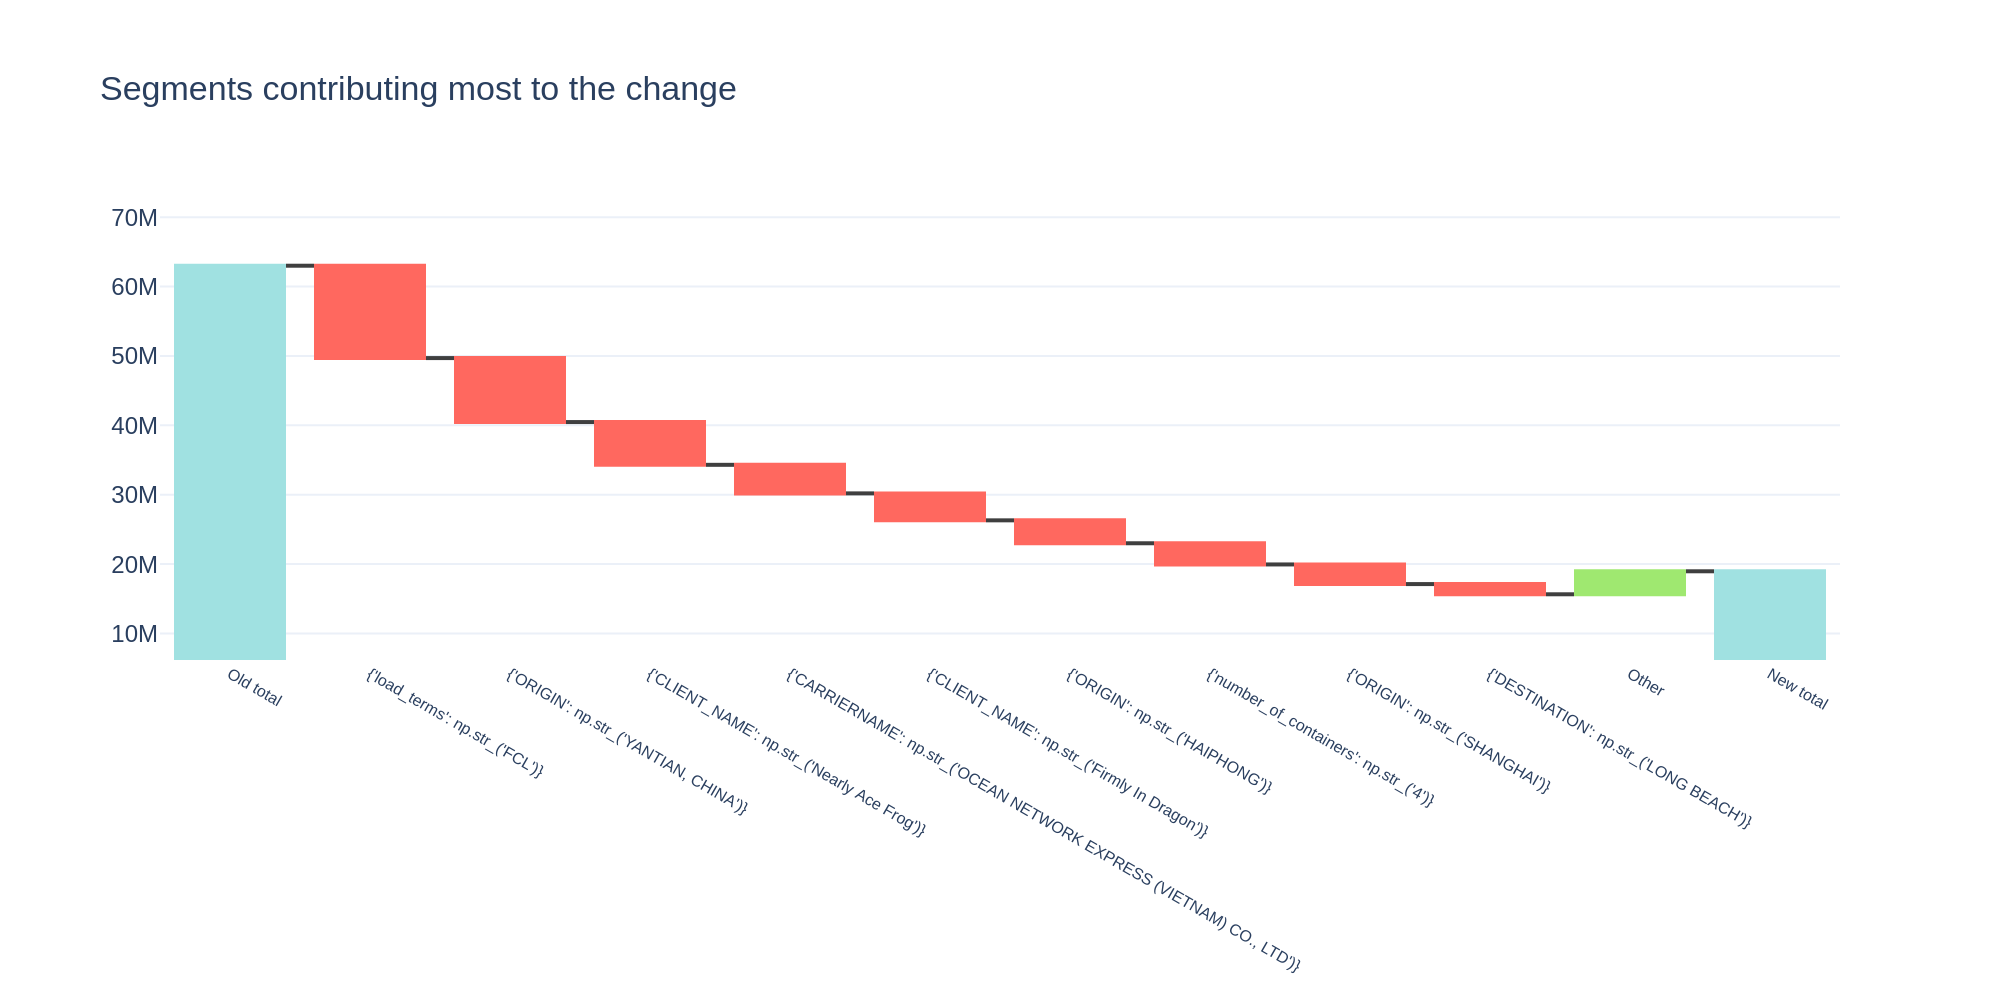

In [32]:
iteration1 = explain_changes_in_totals(
    df1=pre_data,
    df2=data,
    dims=dims,
    total_name=totals,
    size_name=size,
    max_depth=1,
    max_segments=10,
    how="totals",
    solver="lasso"
)

iteration1.plot(width=1000,
                height=500,
                plot_is_static=True)

This concludes biggest attractors and detractors in the volume of revenue that the company generates. 

## Profit Margins

Exploring the profit margins accross different segmentation groups within business. Due to lack of domain knowledge, arbitrarily binning by deciles. 

In [33]:
binned_transactions_query = """

    WITH
        binned_transactions 
    AS (
        SELECT
            NTILE(10) OVER (ORDER BY REVENUE_USD) AS transaction_size_bin, 
            DATE_TRUNC('month', ORDER_DATE) AS transaction_month,
            REVENUE_USD,
            NET_REVENUE_USD
        FROM
            files
        WHERE
            True
            AND order_date <= DATE '2023-11-30'
            
    ),
        profit_margin_analysis 
    AS (
        SELECT
            transaction_month,
            transaction_size_bin,
            COUNT(*) AS transaction_count,
            MIN(REVENUE_USD) AS min_revenue,
            MAX(REVENUE_USD) AS max_revenue,
            SUM(REVENUE_USD) AS total_revenue,
            SUM(NET_REVENUE_USD) AS total_net_revenue,
            SUM(NET_REVENUE_USD
            ) / SUM(REVENUE_USD) AS avg_profit_margin_percentage
        FROM
            binned_transactions
        GROUP BY
            1, 2
    )

    SELECT
        transaction_month,
        CONCAT('Bin ', transaction_size_bin) AS bin_label,
        CONCAT('$', CAST(min_revenue AS INT), ' - $', CAST(max_revenue AS INT)) AS revenue_range,
        transaction_count,
        total_revenue,
        total_net_revenue,
        avg_profit_margin_percentage
    FROM
        profit_margin_analysis
    ORDER BY 
        1, 2;

              """

conn.execute(binned_transactions_query).df()

,transaction_month,bin_label,revenue_range,transaction_count,total_revenue,total_net_revenue,avg_profit_margin_percentage
0,2021-01-01,Bin 1,$160 - $1595,91,97668.12,45136.13,0.46
1,2021-01-01,Bin 10,$173753 - $2578583,38,19802777.03,4078068.36,0.21
2,2021-01-01,Bin 2,$1755 - $4802,84,268592.99,97274.82,0.36
3,2021-01-01,Bin 3,$5164 - $8638,94,628477.93,236721.16,0.38
4,2021-01-01,Bin 4,$8776 - $14388,49,539503.63,176958.16,0.33
...,...,...,...,...,...,...,...
345,2023-11-01,Bin 5,$14580 - $23122,35,623907.21,321487.75,0.52
346,2023-11-01,Bin 6,$23985 - $37416,47,1429356.53,363400.98,0.25
347,2023-11-01,Bin 7,$37754 - $54858,27,1263148.49,256678.17,0.20
348,2023-11-01,Bin 8,$55893 - $89309,46,3188968.80,170393.14,0.05


In [34]:
df = conn.execute(binned_transactions_query).df()

In [35]:
df["transaction_month"] = pd.to_datetime(df["transaction_month"])


pivot_df = df.pivot(index="transaction_month",
                    columns="bin_label",
                    values="avg_profit_margin_percentage")

In [36]:
df = df[df['transaction_month']<='2023-08']

In [37]:
df = df[(df['transaction_month']<='2023-08')
      & (df['bin_label']!='Bin 1')]

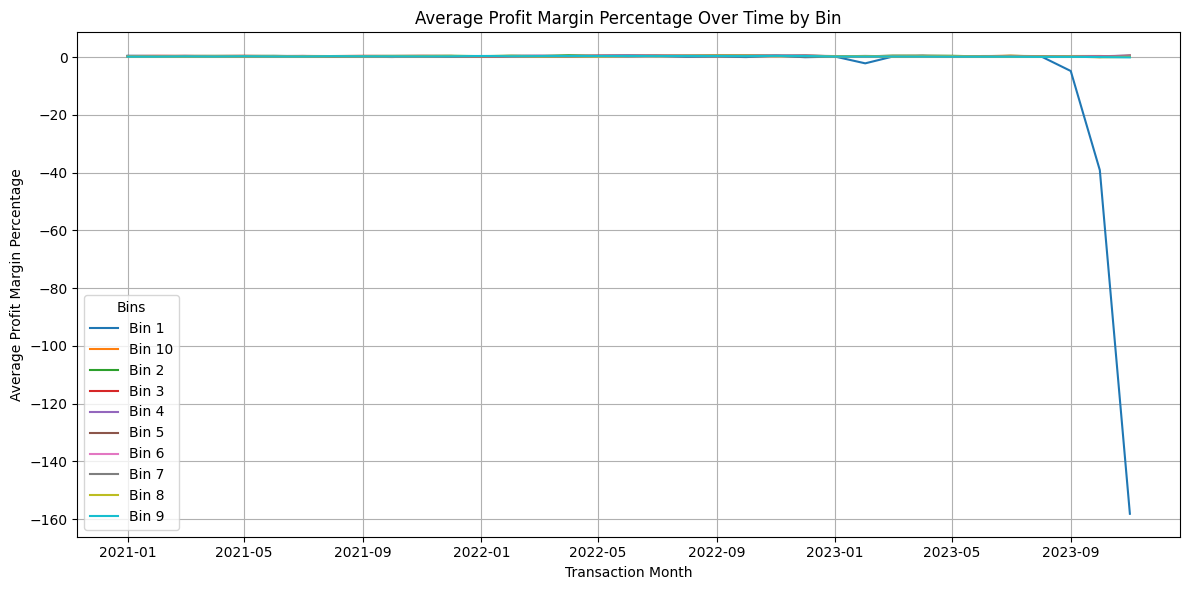

In [38]:
plt.figure(figsize=(12, 6))
for bin_label in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[bin_label], label=bin_label)

# Customizing the plot
plt.title("Average Profit Margin Percentage Over Time by Bin")
plt.xlabel("Transaction Month")
plt.ylabel("Average Profit Margin Percentage")
plt.legend(title="Bins")
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

Target audience for this business should be smaller orders if there is a question of revenue optimization. 
Ideally, this needs to get broked down to identify who those contributors are and how to engage with them for more order placements or how to attract similar segments. 

## Retention Flow

Explore the customer base to identify how many customers are being acquired and retained on a monthly basis. 

In [39]:
retention_flow_query = """

    WITH
        month AS (
            SELECT DISTINCT
                date_trunc('month', order_date) AS month
            FROM
                files
            WHERE 
                TRUE
                AND order_date BETWEEN DATE '2022-10-01' AND DATE '2023-12-31'
        ),
        month_pairs AS (
            SELECT
                m0.month AS month0,
                m1.month AS month1
            FROM 
                month m0
            JOIN 
                month m1
                ON date_add(m0.month, INTERVAL 1 MONTH) = m1.month
        ),
        units AS (
            SELECT
                f.customer_id,
                COALESCE(c.vertical, 'Unknown') AS vertical,
                date_trunc('month', f.order_date) AS trans_month,
                MIN(f.order_date) AS first_transaction_date_in_month,
                MAX(f.order_date) AS last_transaction_date_in_month,
                SUM(f.revenue_usd) AS total_revenue_usd,
                COUNT(DISTINCT f.global_file_id) AS transaction_count
            FROM 
                files f
            LEFT JOIN 
                customers c
                ON f.customer_id = c.customer_id
            GROUP BY 
                1, 2, 3
        )
    
    SELECT
        month0 AS prev_month,
        month1 AS reporting_month,
        'Beginning' AS type,
        u.vertical AS segment,
        u.first_transaction_date_in_month AS reporting_date,
        COUNT(DISTINCT u.customer_id) AS units
    FROM 
        units u
    JOIN 
        month_pairs
        ON u.trans_month = month0
    WHERE 
        date_add(u.first_transaction_date_in_month, INTERVAL 1 MONTH) <= CURRENT_DATE
    GROUP BY 
        1, 2, 3, 4, 5
    
    UNION ALL
    
    SELECT
        month0 AS prev_month,
        month1 AS reporting_month,
        'New' AS type,
        u1.vertical AS segment,
        u1.first_transaction_date_in_month AS reporting_date,
        COUNT(DISTINCT u1.customer_id) AS units
    FROM 
        units u1
    JOIN 
        month_pairs
        ON u1.trans_month = month1
    LEFT JOIN 
        units u0
        ON u1.customer_id = u0.customer_id
        AND u0.trans_month = month0
    WHERE 
        u0.customer_id IS NULL
    GROUP BY 
        1, 2, 3, 4, 5
    
    UNION ALL
    
    SELECT
        month0 AS prev_month,
        month1 AS reporting_month,
        'Revived' AS type,
        u1.vertical AS segment,
        u1.first_transaction_date_in_month AS reporting_date,
        COUNT(DISTINCT u1.customer_id) AS units
    FROM 
        units u1
    JOIN 
        month_pairs
        ON u1.trans_month = month1
    LEFT JOIN 
        units u0
        ON u1.customer_id = u0.customer_id
        AND u0.trans_month = month0
    WHERE 
        u0.customer_id IS NULL
        AND u1.first_transaction_date_in_month <= month0
    GROUP BY 
        1, 2, 3, 4, 5
    
    UNION ALL
    
    SELECT
        month0 AS prev_month,
        month1 AS reporting_month,
        'Attrition' AS type,
        u0.vertical AS segment,
        date_add(u0.last_transaction_date_in_month,  INTERVAL 1 MONTH) AS reporting_date,
        COUNT(DISTINCT u0.customer_id) AS units
    FROM 
        units u0
    JOIN 
        month_pairs
        ON u0.trans_month = month0
    LEFT JOIN 
        units u1
        ON u1.customer_id = u0.customer_id
        AND u1.trans_month = month1
    WHERE 
        u1.customer_id IS NULL
    GROUP BY 
        1, 2, 3, 4, 5
    
    UNION ALL
    
    SELECT
        month0 AS prev_month,
        month1 AS reporting_month,
        'Ending' AS type,
        u.vertical AS segment,
        u.last_transaction_date_in_month AS reporting_date,
        COUNT(DISTINCT u.customer_id) AS units
    FROM 
        units u
    JOIN 
        month_pairs
        ON u.trans_month = month1
    GROUP BY 
        1, 2, 3, 4, 5;

              """

conn.execute(retention_flow_query).df()

,prev_month,reporting_month,type,segment,reporting_date,units
0,2023-04-01,2023-05-01,Beginning,Retail,2023-04-11,1
1,2023-06-01,2023-07-01,Beginning,Industrial,2023-06-30,1
2,2023-01-01,2023-02-01,Beginning,Industrial,2023-01-05,4
3,2023-05-01,2023-06-01,Beginning,Industrial,2023-05-04,2
4,2023-02-01,2023-03-01,Beginning,Doc Turnover,2023-02-01,1
...,...,...,...,...,...,...
2139,2022-10-01,2022-11-01,Ending,Industrial,2022-11-21,1
2140,2023-01-01,2023-02-01,Ending,Life Science,2023-02-09,1
2141,2023-06-01,2023-07-01,Ending,Industrial,2023-07-26,1
2142,2023-04-01,2023-05-01,Ending,Energy,2023-05-19,1


Business units are a great indicator of customer base health, but this metric should be weighted using respective domain knowledge. 

In [40]:
retention_flow_df = conn.execute(retention_flow_query).df()
retention_flow_df['reporting_month'] = pd.to_datetime(retention_flow_df['reporting_month'])

In [41]:
aggregated_df = retention_flow_df.groupby(['reporting_month', 'type']).agg(
    {'units': 'sum'}
).reset_index()

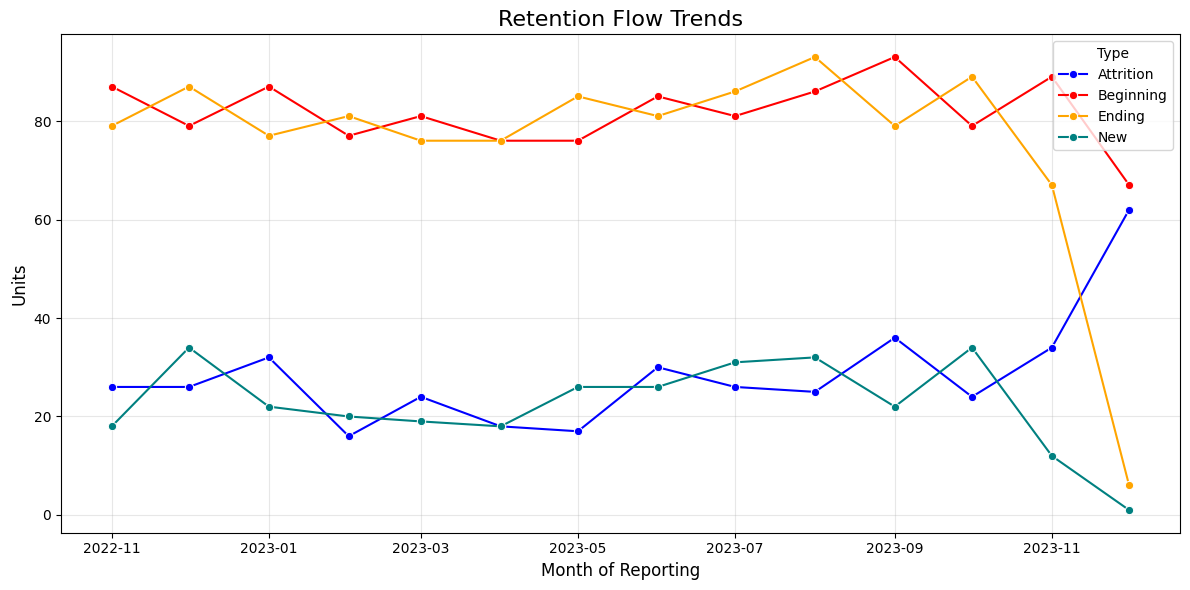

In [42]:
plt.figure(figsize=(12, 6))

# Line plot for each type
sns.lineplot(
    data=aggregated_df,
    x='reporting_month',
    y='units',
    hue='type',
    palette=['blue', 'red', 'orange', 'teal'],  # Custom colors
    marker='o'
)

# Customize the plot
plt.title('Retention Flow Trends', fontsize=16)
plt.xlabel('Month of Reporting', fontsize=12)
plt.ylabel('Units', fontsize=12)
plt.legend(title='Type', loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()

# Show the plot
plt.show()

Next, one would slice the unit flow based on different segments to find the insights. 

## KPI Readout

Leverage the one big table (OBT) that was created to start initial drafting of the plots that can be later be transerred to BI tool for more robust functionality.

In [43]:
obt_df = conn.execute(joins_query).df()
obt_df

,GLOBAL_FILE_ID,CUSTOMER_ID,PRODUCT,ORDER_DATE,CARRIER_ID,CARRIERNAME,DESTINATION_COUNTRY,DESTINATION_CITY,DESTINATION,ORIGIN_COUNTRY,ORIGIN_CITY,ORIGIN,DELIVERY_DATE,REQUESTED_DELIVERY_DATE,REVENUE_USD,NET_REVENUE_USD,CLIENT_NAME,VERTICAL,load_terms,vessel,voyage,quantity,teu,number_of_containers
0,af9ee78126b07b68072238c83684ab9d,c9de820d0ad0631c6be0600200d33500,OCEAN,2022-08-30,077ec7a0b2cd4b2830315dc2169b21de,HAPAG-LLOYD (CHINA) LTD,IT,LSP,LA SPEZIA,CN,QDG,QINGDAO PT,2022-11-11,2022-11-25,108578.79,25818.16,Saved Stag,Industrial,FCL,AL RIFFA,021W,1 X 40OT,2.00,1
1,41ff3ab13021859df16b1d91c4ea6aba,61c3e2f28f60c7fd7f879dd19e9a22ff,OCEAN,2022-08-30,c68307500ae6d799f8abe045f7b6908d,YANG MING MARINE TRANSPORT CORP,CA,VAN,VANCOUVER,CN,SGH,SHANGHAI,2022-10-21,2022-11-30,126644.71,29321.97,Loudly Steady Bee,Industrial,FCL,YM THRONE,001E,1 X 40,2.00,1
2,2cce8cadf5ff04e051ffcf233392fbe2,813a749fcc0d31838ffb717a685de432,OCEAN,2022-08-31,58437d0eae7c11093d9212b2e4ab94f2,EVERGREEN SHIPPING AGENCY (VIETNAM),US,HOU,HOUSTON,VN,HPH,HAIPHONG,2022-11-07,2022-11-11,594841.50,122583.55,Nearly Ace Frog,Retail,FCL,ONE MARVEL,061E,4 X 40HC,8.00,4
3,727a5c98ea7bdd2e1132791f3a82e1e5,77272b777a9f0c0d6f94e0fa1be5d3ad,RAIL,2022-08-31,aed0e0d08b13282d5f41c311aac528d5,FAR EAST LAND BRIDGE LTD,CN,HFI,HEFEI,DE,HAT,HATTINGEN,2022-09-02,2022-09-30,5022.97,882.64,Weekly Enough Cicada,Industrial,FCL,RAIL,EB220826,1 X 40HC,2.00,1
4,b282713ad20dc9429296b05970cbcf4d,388ad24b3d4c9502a5e4aa39c7383abc,OCEAN,2022-08-31,7c7a87db4d3d96486d929522dcbcbe56,"COSCO CONTAINER LINES CO.,LTD",US,NYC,NEW YORK,CN,SGH,SHANGHAI,2022-10-11,2022-11-30,128059.21,9831.56,Firmly In Dragon,Automotive,FCL,COSCO DEVELOPMENT,061E,1 X 40HC,2.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22252,14e5f9a4f5c3a5e3eba40755a0bf3bda,7456259d70fdd2b2c5d88a928ae4e7f4,GROUND,2023-10-23,3d7d04bae506db89e82d6f27229d7aa0,DHESI ENTERPRISES LTD,None,None,None,CA,YEG,EDMONTON,2023-11-03,2023-11-03,6498.00,3159.75,None,None,None,None,None,None,NaN,<NA>
22253,96b95113e03a4a073005998a1223306b,357be8af9c60503ca4a452ab185f5cc3,AIR,2022-05-31,6aa451b53d492a8f5a2fa1fa2855be8b,Emirates,IE,ORK,CORK,TW,TPE,TAIPEI,2022-06-09,2022-06-10,189875.42,39304.45,None,None,None,None,None,None,NaN,<NA>
22254,1ea01497d5c91881b4cce1d7379894f9,357be8af9c60503ca4a452ab185f5cc3,AIR,2022-04-27,5fc810cf62601df84b7923b9964c53e6,British Airways p.l.c.,IE,ORK,CORK,US,SFO,SAN FRANCISCO,2022-05-05,2022-05-10,8733.17,2511.11,None,None,None,None,None,None,NaN,<NA>
22255,9bd2c2524fecf979c06a572ef6e40b70,113c6fa72595bdf7c4474bf962d0ccef,AIR,2021-03-30,b312cc8653ffd4c30bce0e071cefb600,Turkish Airlines Inc.,TR,ISL,ISTANBUL ATATURK AIRPORT,None,None,None,NaT,2021-04-09,34331.22,6186.40,None,None,None,None,None,None,NaN,<NA>


Create a function that will do plotting of two columns and would fit a first-degree polinomial as a trend line. 

In [44]:
def plot_trend_with_lines(
    df, x_col, y_cols, labels, title, ylabel, colors=None, figsize=(12, 6)
):
    """
    Plots trends with optional trendlines for multiple y-columns.

    Parameters:
        df (pd.DataFrame): The input data.
        x_col (str): The column for the x-axis.
        y_cols (list): List of columns to plot on the y-axis.
        labels (list): Labels for the y-columns (used in the legend).
        title (str): Title of the plot.
        ylabel (str): Label for the y-axis.
        colors (list): Optional list of colors for the lines (default seaborn colors).
        figsize (tuple): Figure size (default is (12, 6)).
    """
    if colors is None:
        colors = sns.color_palette("deep", len(y_cols))  # Default colors

    # Create the plot
    plt.figure(figsize=figsize)

    # Loop through each y-column to plot
    for y_col, label, color in zip(y_cols, labels, colors):
        # Plot the line
        sns.lineplot(x=x_col, y=y_col, data=df, label=label, color=color)

        # Add the trendline
        z = np.polyfit(df[x_col].map(pd.Timestamp.toordinal), df[y_col], 1)
        p = np.poly1d(z)
        plt.plot(
            df[x_col],
            p(df[x_col].map(pd.Timestamp.toordinal)),
            linestyle="--",
            color=color,
            alpha=0.7,
            label=f"{label} Trend",
        )

    # Customize the plot
    plt.title(title, fontsize=16)
    plt.xlabel("Year", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend(title="Measure Names", loc="best")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    # Display the plot
    plt.show()

In [45]:
# Convert 'order_date' to datetime if not already
obt_df['ORDER_DATE'] = pd.to_datetime(obt_df['ORDER_DATE'])

# Create 'revenue_year' by truncating to the year
obt_df['revenue_year'] = obt_df['ORDER_DATE'].dt.to_period('Y')

# Aggregate data
feature_matrix_df = obt_df.groupby('revenue_year').agg({
    'NET_REVENUE_USD': 'sum',    # Total Net Revenue
    'REVENUE_USD': 'sum'         # Total Revenue
}).reset_index()

# Convert 'revenue_year' back to datetime for plotting
feature_matrix_df['revenue_year'] = feature_matrix_df['revenue_year'].dt.start_time

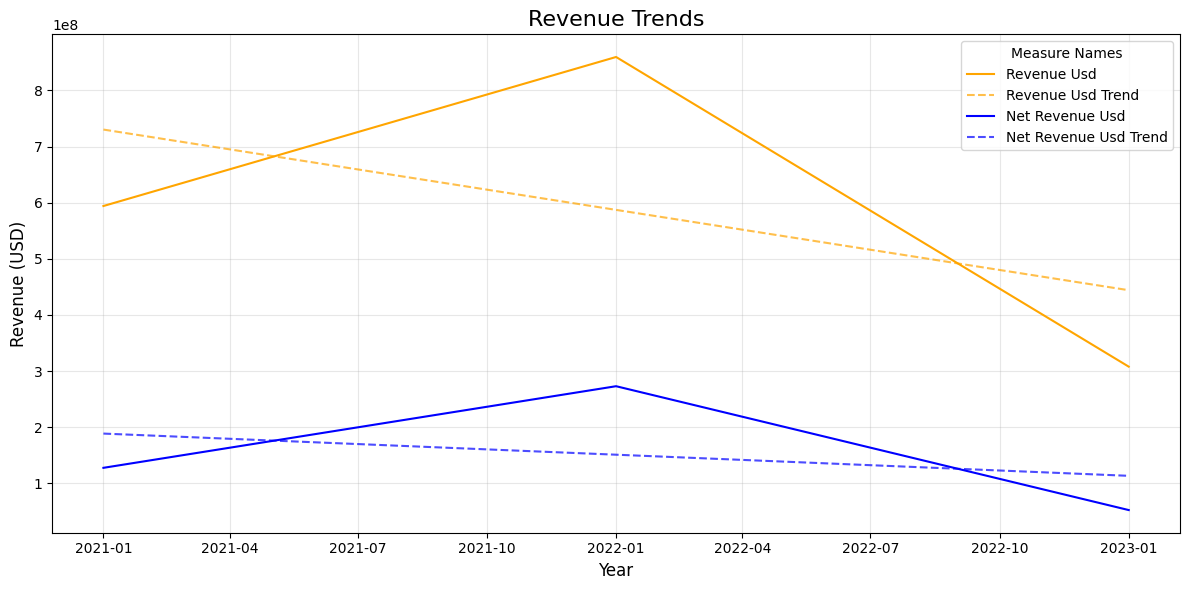

In [46]:
plot_trend_with_lines(
    df=feature_matrix_df,
    x_col="revenue_year",
    y_cols=["REVENUE_USD", "NET_REVENUE_USD"],
    labels=["Revenue Usd", "Net Revenue Usd"],
    title="Revenue Trends",
    ylabel="Revenue (USD)",
    colors=["orange", "blue"],  # Custom colors for the lines
)


For `origin` and `destination`, accept the assumption that the locations are standardized and validated appropriately. 

In [47]:
obt_df['order_date'] = pd.to_datetime(obt_df['ORDER_DATE'])
obt_df['revenue_year'] = obt_df['ORDER_DATE'].dt.to_period('Y')

# Aggregate data to calculate distinct counts
country_trends_df = obt_df.groupby('revenue_year').agg(
    distinct_destination_country=('DESTINATION', 'nunique'),
    distinct_origin_country=('ORIGIN', 'nunique')
).reset_index()

# Convert 'revenue_year' back to datetime for plotting
country_trends_df['revenue_year'] = country_trends_df['revenue_year'].dt.start_time

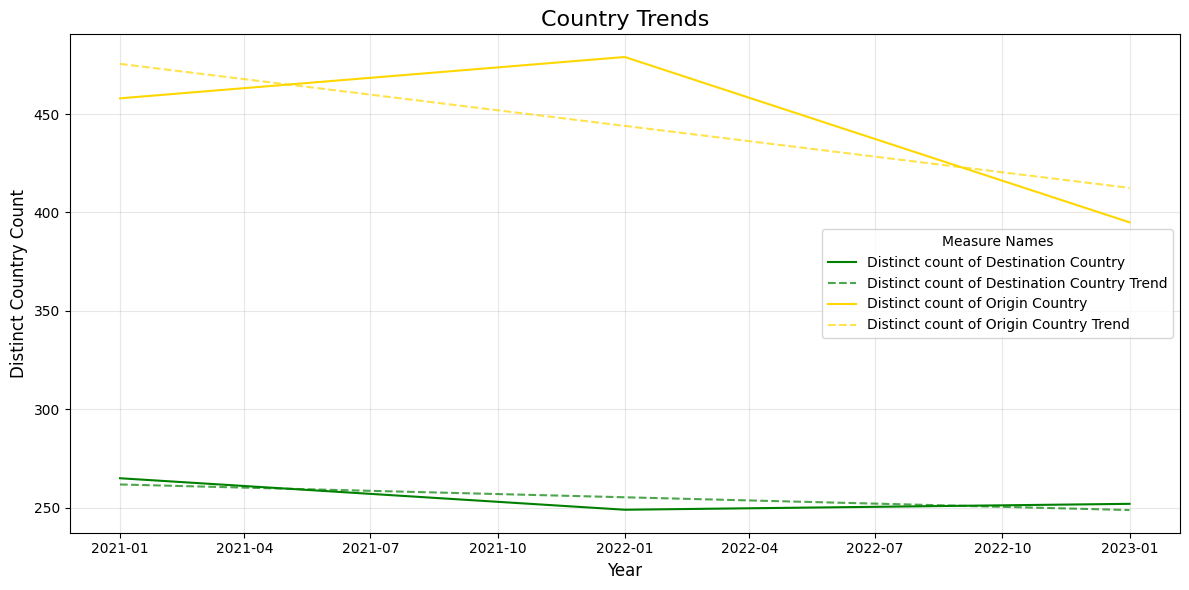

In [48]:
plot_trend_with_lines(
    df=country_trends_df,
    x_col="revenue_year",
    y_cols=["distinct_destination_country", "distinct_origin_country"],
    labels=["Distinct count of Destination Country", "Distinct count of Origin Country"],
    title="Country Trends",
    ylabel="Distinct Country Count",
    colors=["green", "gold"],  # Custom colors for the lines
)

In [49]:
obt_df['order_date'] = pd.to_datetime(obt_df['order_date'])
obt_df['revenue_year'] = obt_df['order_date'].dt.to_period('Y')

# Aggregate data to calculate distinct counts for customers and carriers
customer_carrier_trends_df = obt_df.groupby('revenue_year').agg(
    count_customers=('CUSTOMER_ID', 'nunique'),
    count_carriers=('CARRIERNAME', 'nunique')
).reset_index()

# Convert 'revenue_year' back to datetime for plotting
customer_carrier_trends_df['revenue_year'] = customer_carrier_trends_df['revenue_year'].dt.start_time

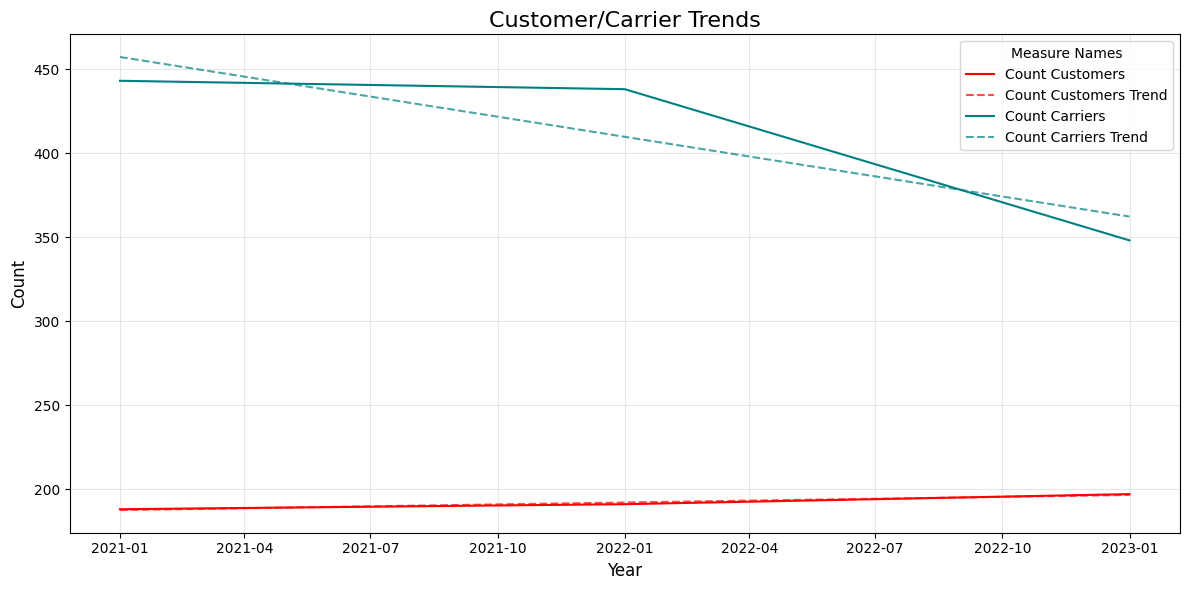

In [50]:
plot_trend_with_lines(
    df=customer_carrier_trends_df,
    x_col="revenue_year",
    y_cols=["count_customers", "count_carriers"],
    labels=["Count Customers", "Count Carriers"],
    title="Customer/Carrier Trends",
    ylabel="Count",
    colors=["red", "teal"],  # Optional: specify custom colors
)

---

In [51]:
conn.close()